# IMDb Movie Review Sentiment Analysis

## Objective
To classify movie reviews as positive or negative using Machine Learning and Natural Language Processing.

## Dataset
IMDb Movie Reviews Dataset (50,000 Reviews)

## Algorithm
Logistic Regression

## Feature Extraction
TF-IDF Vectorization

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [159]:
df = pd.read_csv("IMDB_Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


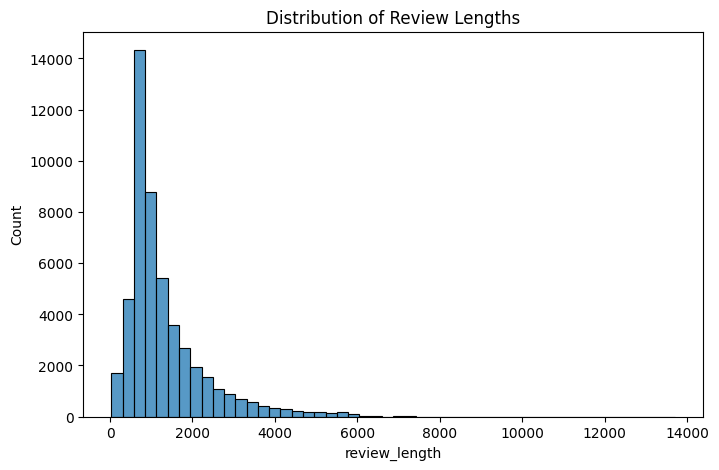

In [160]:
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    df['review_length'],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.show()

In [161]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (50000, 3)

Columns:
Index(['review', 'sentiment', 'review_length'], dtype='str')

Missing Values:
review           0
sentiment        0
review_length    0
dtype: int64


In [162]:
print(df.isnull().sum())

review           0
sentiment        0
review_length    0
dtype: int64


In [163]:
df['review_length'] = df['review'].apply(len)

df['review_length'].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

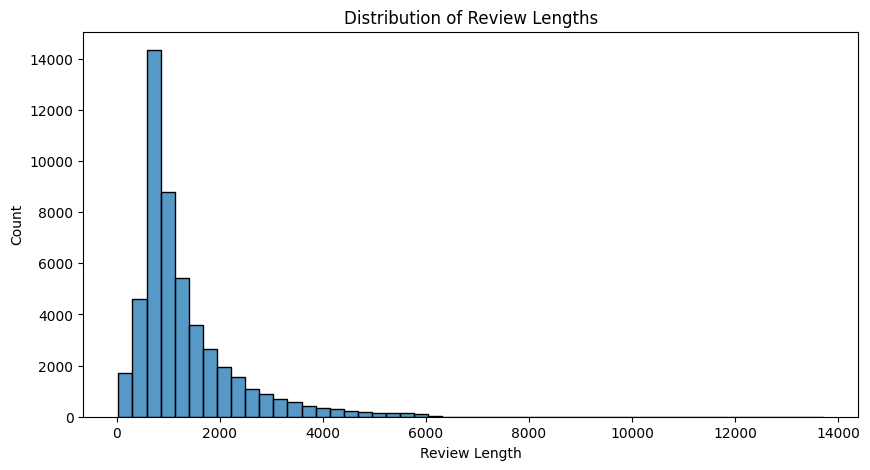

In [164]:
plt.figure(figsize=(10,5))

sns.histplot(df['review_length'], bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length")
plt.ylabel("Count")

plt.show()

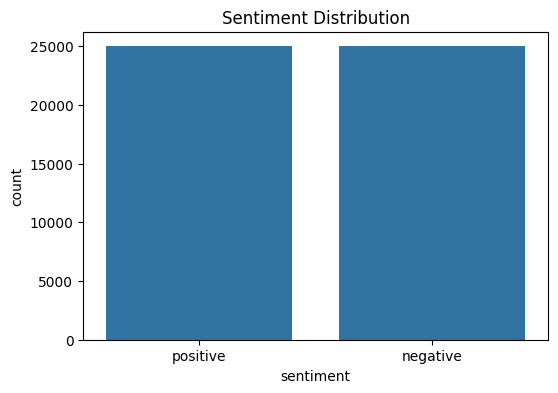

In [165]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

In [166]:
X = df['review']
y = df['sentiment']

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

print("Starting TF-IDF...")

X = vectorizer.fit_transform(X)

print("Done!")

Starting TF-IDF...
Done!


In [167]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (40000, 5000)
Testing Shape: (10000, 5000)


In [168]:
model = LogisticRegression(max_iter=1000)

print("Training Model...")

model.fit(X_train, y_train)

print("Training Complete!")

Training Model...
Training Complete!


In [169]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 88.96 %


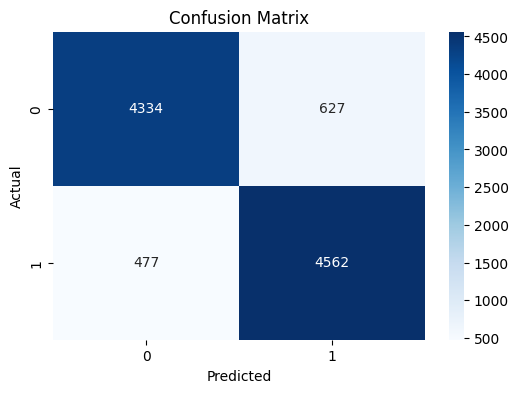

In [170]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [171]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.90      0.87      0.89      4961
    positive       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [172]:
review = [
    "This movie was absolutely amazing and I loved every moment."
]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print("Prediction:", prediction[0])

Prediction: positive


In [173]:
review = [
    "Worst movie ever. Total waste of time."
]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print("Prediction:", prediction[0])

Prediction: negative


# Conclusion

The IMDb Sentiment Analysis model was successfully developed using TF-IDF Vectorization and Logistic Regression.

The model achieved high accuracy in classifying movie reviews as positive or negative.

This project demonstrates the application of Natural Language Processing (NLP) and Machine Learning in sentiment classification.